# Pipeline A — Pose Estimation

**InterviewLens · MSADS Advanced Computer Vision (31023) · Final Project**

This notebook implements **Problem 1** of the InterviewLens system: estimating upper-body
pose and framing quality from a recorded interview video. It is a **keypoint regression /
heatmap localization** problem — a distinct cognitive task from Notebook 2's object
detection problem, satisfying the course rubric's requirement for two different cognitive
problems.

## What this notebook does

1. Loads and inspects a COCO-keypoints subset (EDA).
2. Runs the **champion** model — **RTMPose-S**, a modern one-stage heatmap pose estimator
   (via `rtmlib`, ONNX Runtime — no `mmcv`/`mmdet` build required).
3. Implements and trains the **challenger** model — **SimpleBaseline**, a classic
   ResNet-backbone + deconvolutional heatmap head, written from scratch.
4. Derives **framing & subject-region geometry** (bounding box, headroom, centering, roll)
   from keypoints — this feeds Notebook 2's person-suppression step.
5. Evaluates both models with PCK@0.2, OKS-AP, MPJPE, and efficiency metrics.
6. Runs the champion model on the project's demo interview video and exports
   `outputs/pose_evidence.json` — the structured evidence package consumed by
   Notebook 3 (Evidence Fusion & Timeline).

## Champion vs. Challenger

| | Champion | Challenger |
|---|---|---|
| Model | RTMPose-S | SimpleBaseline (ResNet + deconv head) |
| Paradigm | Modern one-stage heatmap regression, SimCC head | Classic two-stage: backbone features -> deconv upsampling -> heatmap |
| Weights | Pretrained (COCO), ONNX | ImageNet-pretrained backbone; deconv head trained from scratch here |
| Expectation | Faster, more accurate out-of-the-box | Slower to converge, more transparent/implementable, useful baseline |

See `../SKILLS.md` for the full technique reference and `../CLAUDE.md` for project scope.


## 1. Setup

Run this notebook with the `cv_env` virtualenv / Jupyter kernel
(`/home/arcanegus/MSADS_/advanced_cv_31023/cv_env`). New packages beyond the course
`requirements.txt` needed for this notebook: `pycocotools`, `torchmetrics`, `rtmlib`.


In [1]:
# !pip install -q pycocotools torchmetrics rtmlib

import json
import random
import time
import zipfile
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import models as tv_models

DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
MODEL_DIR = Path("saved_models")
for d in (DATA_DIR, OUTPUT_DIR, MODEL_DIR):
    d.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Using device: cuda
GPU: NVIDIA GeForce RTX 5080 Laptop GPU


## 2. Demo Interview Video

All three InterviewLens notebooks share the same source video so that Notebook 3's fused
timeline reflects one consistent recording. The clip used here is
`data/demo_interview.mp4` — a single person talking to camera in a webcam-style shot.

> **Source / license**: *TODO — confirm and cite before this notebook is included in the
> final report submission.*


In [3]:
from shared_video import load_verified_video_path, start_run_dir

# Loaded + checksum-verified against configs/config.yaml (single source of truth shared
# with every other notebook) -- see CLAUDE.md > "Shared demo video".
DEMO_VIDEO_PATH = load_verified_video_path(DATA_DIR)

# Fresh, timestamped output directory for this run -- Notebooks 2 and 3 pick up the same
# directory via current_run_dir() instead of each writing into a shared outputs/ that
# silently overwrote the previous run's evidence. See shared_video.py for the rationale.
OUTPUT_DIR = start_run_dir(DEMO_VIDEO_PATH, OUTPUT_DIR)
print(f"Run output directory: {OUTPUT_DIR}")

cap = cv2.VideoCapture(str(DEMO_VIDEO_PATH))
VIDEO_FPS = cap.get(cv2.CAP_PROP_FPS)
VIDEO_FRAME_COUNT = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
VIDEO_WIDTH = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
VIDEO_HEIGHT = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
VIDEO_DURATION_S = VIDEO_FRAME_COUNT / VIDEO_FPS
cap.release()

print(f"Duration:    {VIDEO_DURATION_S:.1f} s")
print(f"Source FPS:  {VIDEO_FPS:.2f}")
print(f"Frame count: {VIDEO_FRAME_COUNT}")
print(f"Resolution:  {VIDEO_WIDTH}x{VIDEO_HEIGHT}")

POSE_SAMPLE_FPS = 5  # per pipeline_detallado.png: 30fps decode -> 5fps stride for pose


Run output directory: outputs/test_20260811_184726
Duration:    24.9 s
Source FPS:  29.98
Frame count: 745
Resolution:  1920x1080


## 3. Exploratory Data Analysis — COCO Keypoints

We use the **COCO val2017** split filtered to images with person-keypoint annotations as
our pose dataset: it's a single ~1 GB image download (vs. 18 GB for train2017), and it
already contains a natural, manageable subset (~2.7k images with keypoints) — no separate
sampling step needed. This subset is used for EDA, SimpleBaseline fine-tuning, and
held-out evaluation of both models.

Source: [COCO 2017](https://cocodataset.org/#download) — images and annotations are
released under a [Creative Commons Attribution 4.0 license](https://cocodataset.org/#termsofuse).


In [4]:
def download(url: str, dest: Path, chunk_size: int = 1 << 20) -> None:
    if dest.exists():
        print(f"Already downloaded: {dest}")
        return
    print(f"Downloading {url} -> {dest}")
    with requests.get(url, stream=True, timeout=60) as r:
        r.raise_for_status()
        tmp = dest.with_suffix(dest.suffix + ".part")
        with open(tmp, "wb") as f:
            for chunk in r.iter_content(chunk_size=chunk_size):
                f.write(chunk)
        tmp.rename(dest)


def unzip(zip_path: Path, dest_dir: Path) -> None:
    marker = dest_dir / f".{zip_path.stem}_extracted"
    if marker.exists():
        print(f"Already extracted: {zip_path.name}")
        return
    print(f"Extracting {zip_path.name} ...")
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(dest_dir)
    marker.touch()


COCO_DIR = DATA_DIR / "coco"
COCO_DIR.mkdir(exist_ok=True)

ANN_ZIP = COCO_DIR / "annotations_trainval2017.zip"
IMG_ZIP = COCO_DIR / "val2017.zip"

download("http://images.cocodataset.org/annotations/annotations_trainval2017.zip", ANN_ZIP)
download("http://images.cocodataset.org/zips/val2017.zip", IMG_ZIP)

unzip(ANN_ZIP, COCO_DIR)
unzip(IMG_ZIP, COCO_DIR)

COCO_ANN_PATH = COCO_DIR / "annotations" / "person_keypoints_val2017.json"
COCO_IMG_DIR = COCO_DIR / "val2017"
assert COCO_ANN_PATH.exists() and COCO_IMG_DIR.exists()


Already downloaded: data/coco/annotations_trainval2017.zip
Already downloaded: data/coco/val2017.zip
Already extracted: annotations_trainval2017.zip
Already extracted: val2017.zip


In [5]:
# COCO-17 keypoint order (used by both the annotation format and RTMPose's COCO output)
COCO17_NAMES = [
    "nose", "left_eye", "right_eye", "left_ear", "right_ear",
    "left_shoulder", "right_shoulder", "left_elbow", "right_elbow",
    "left_wrist", "right_wrist", "left_hip", "right_hip",
    "left_knee", "right_knee", "left_ankle", "right_ankle",
]
# The 11 upper-body joints InterviewLens tracks (indices into COCO17_NAMES)
UPPER_BODY_IDX = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
UPPER_BODY_NAMES = [COCO17_NAMES[i] for i in UPPER_BODY_IDX]
print(UPPER_BODY_NAMES)

with open(COCO_ANN_PATH) as f:
    coco = json.load(f)

images_by_id = {im["id"]: im for im in coco["images"]}
anns_by_image = {}
for ann in coco["annotations"]:
    if ann["num_keypoints"] > 0:
        anns_by_image.setdefault(ann["image_id"], []).append(ann)

print(f"Total val2017 images: {len(coco['images'])}")
print(f"Images with >=1 person keypoint annotation: {len(anns_by_image)}")
print(f"Total keypoint annotations: {sum(len(v) for v in anns_by_image.values())}")


['nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear', 'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow', 'left_wrist', 'right_wrist']


Total val2017 images: 5000
Images with >=1 person keypoint annotation: 2346
Total keypoint annotations: 6352


In [6]:
# Filter to single-person images: simplest, unambiguous supervision signal for a
# per-image heatmap target (multi-person images would need instance cropping we're not
# doing here). This mirrors FLIC's single-person convention referenced in the design doc.
records = []
for image_id, anns in anns_by_image.items():
    if len(anns) != 1:
        continue
    ann = anns[0]
    img = images_by_id[image_id]
    kpts = np.array(ann["keypoints"], dtype=np.float32).reshape(17, 3)  # x, y, v
    records.append({
        "image_id": image_id,
        "file_name": img["file_name"],
        "width": img["width"],
        "height": img["height"],
        "bbox": ann["bbox"],  # xywh
        "num_keypoints": ann["num_keypoints"],
        "keypoints": kpts,
    })

df = pd.DataFrame(records)
print(f"Single-person images with keypoints: {len(df)}")
df[["image_id", "file_name", "width", "height", "num_keypoints"]].head()


Single-person images with keypoints: 1098


,image_id,file_name,width,height,num_keypoints
0,425226,000000425226.jpg,480,640,10
1,440475,000000440475.jpg,640,427,13
2,458992,000000458992.jpg,480,640,13
3,481567,000000481567.jpg,640,480,13
4,329614,000000329614.jpg,500,208,9


### 3.1 Schema, record counts, missing values


In [7]:
# Visibility flag v: 0 = not labeled, 1 = labeled but occluded, 2 = labeled and visible
vis_counts = np.zeros((17, 3), dtype=int)
for kpts in df["keypoints"]:
    for j in range(17):
        v = int(kpts[j, 2])
        vis_counts[j, v] += 1

vis_df = pd.DataFrame(vis_counts, columns=["missing (v=0)", "occluded (v=1)", "visible (v=2)"], index=COCO17_NAMES)
vis_df["pct_missing"] = (vis_df["missing (v=0)"] / len(df) * 100).round(1)
print("Record counts:", len(df))
print("Schema:", dict(df.dtypes.astype(str)))
vis_df


Record counts: 1098
Schema: {'image_id': 'int64', 'file_name': 'object', 'width': 'int64', 'height': 'int64', 'bbox': 'object', 'num_keypoints': 'int64', 'keypoints': 'object'}


,missing (v=0),occluded (v=1),visible (v=2),pct_missing
nose,305,28,765,27.8
left_eye,393,6,699,35.8
right_eye,405,11,682,36.9
left_ear,523,23,552,47.6
right_ear,493,47,558,44.9
left_shoulder,157,39,902,14.3
right_shoulder,155,29,914,14.1
left_elbow,292,45,761,26.6
right_elbow,274,50,774,25.0
left_wrist,276,54,768,25.1


### 3.2 Univariate & bivariate keypoint analysis


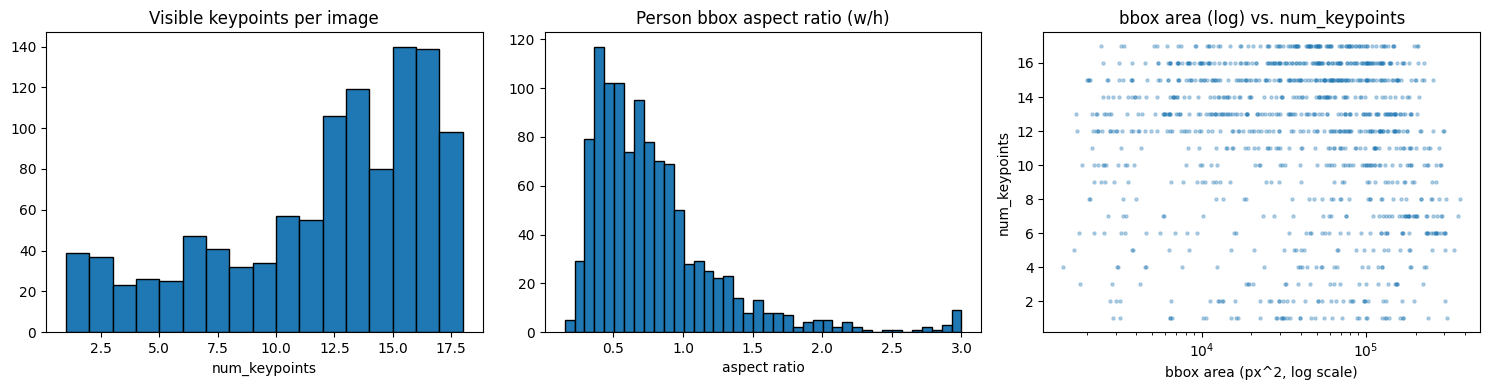

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Univariate: distribution of num_keypoints per image
axes[0].hist(df["num_keypoints"], bins=range(1, 19), edgecolor="black")
axes[0].set_title("Visible keypoints per image")
axes[0].set_xlabel("num_keypoints")

# Univariate: bbox aspect ratio
aspect = df["bbox"].apply(lambda b: b[2] / max(b[3], 1e-6))
axes[1].hist(aspect.clip(0, 3), bins=40, edgecolor="black")
axes[1].set_title("Person bbox aspect ratio (w/h)")
axes[1].set_xlabel("aspect ratio")

# Bivariate: bbox area vs num_keypoints (does small scale hurt annotation density?)
bbox_area = df["bbox"].apply(lambda b: b[2] * b[3])
axes[2].scatter(bbox_area, df["num_keypoints"], s=5, alpha=0.3)
axes[2].set_xscale("log")
axes[2].set_title("bbox area (log) vs. num_keypoints")
axes[2].set_xlabel("bbox area (px^2, log scale)")
axes[2].set_ylabel("num_keypoints")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_univariate_bivariate.png", dpi=120)
plt.show()


### 3.3 Sample images with skeleton overlay


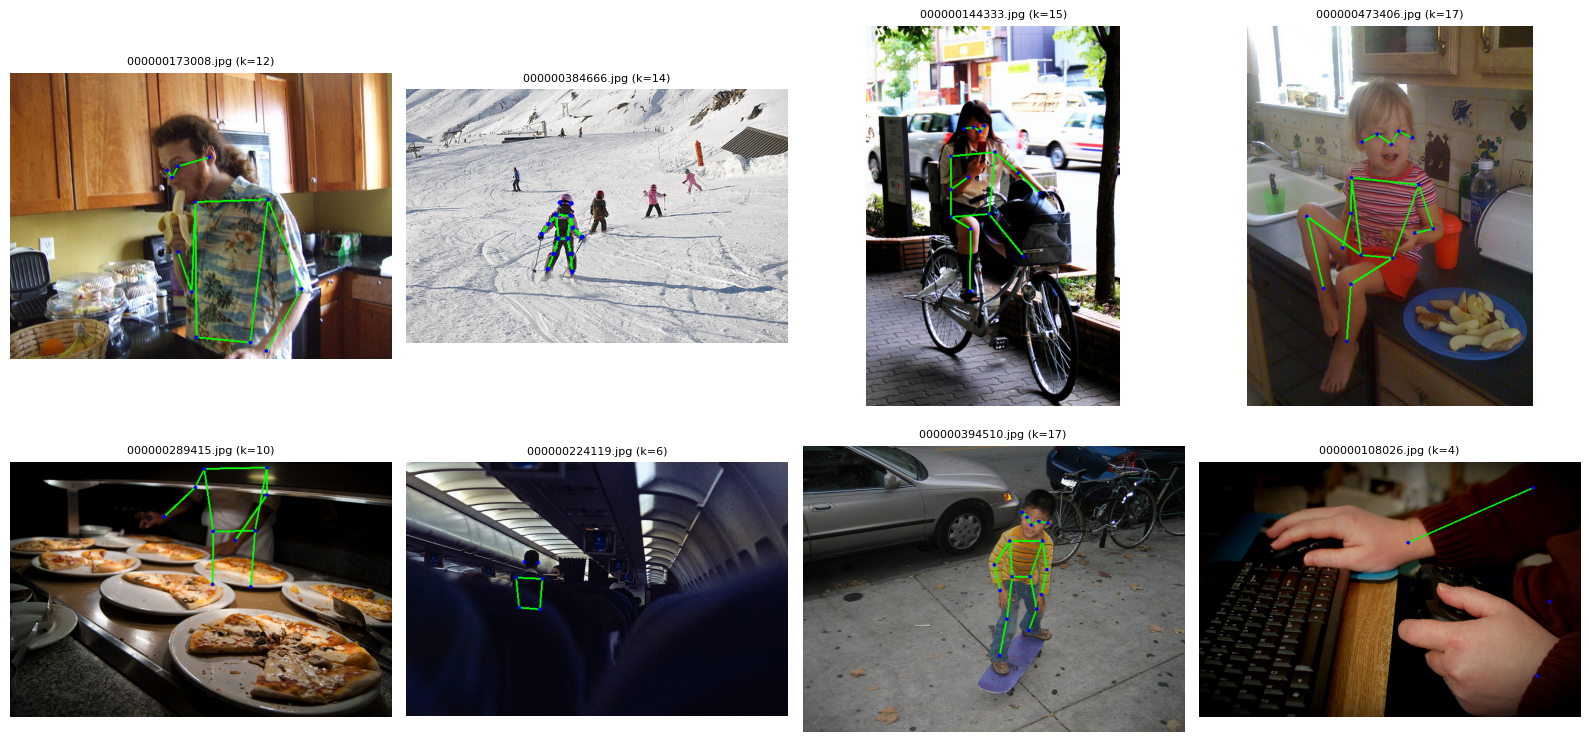

In [9]:
COCO17_SKELETON = [
    (0, 1), (0, 2), (1, 3), (2, 4),  # face
    (5, 6), (5, 7), (7, 9), (6, 8), (8, 10),  # arms
    (5, 11), (6, 12), (11, 12),  # torso
    (11, 13), (13, 15), (12, 14), (14, 16),  # legs
]


def draw_skeleton(img: np.ndarray, kpts: np.ndarray, edges=COCO17_SKELETON, color=(0, 255, 0)) -> np.ndarray:
    out = img.copy()
    for (a, b) in edges:
        if kpts[a, 2] > 0 and kpts[b, 2] > 0:
            pa, pb = tuple(kpts[a, :2].astype(int)), tuple(kpts[b, :2].astype(int))
            cv2.line(out, pa, pb, color, 2)
    for j in range(kpts.shape[0]):
        if kpts[j, 2] > 0:
            cv2.circle(out, tuple(kpts[j, :2].astype(int)), 3, (0, 0, 255), -1)
    return out


sample_rows = df.sample(n=8, random_state=SEED)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (_, row) in zip(axes.flat, sample_rows.iterrows()):
    img = cv2.imread(str(COCO_IMG_DIR / row["file_name"]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = draw_skeleton(img, row["keypoints"])
    ax.imshow(img)
    ax.set_title(f"{row['file_name']} (k={row['num_keypoints']})", fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_sample_skeletons.png", dpi=120)
plt.show()


### 3.4 Outliers

Flag images with an extreme bbox aspect ratio (very wide or very tall relative to a normal
standing/sitting person) or very few labeled upper-body keypoints — these are the frames
most likely to break a pose model at inference time.


In [10]:
def upper_body_visible_count(kpts: np.ndarray) -> int:
    return int((kpts[UPPER_BODY_IDX, 2] > 0).sum())


df["aspect_ratio"] = df["bbox"].apply(lambda b: b[2] / max(b[3], 1e-6))
df["upper_body_visible"] = df["keypoints"].apply(upper_body_visible_count)

aspect_lo, aspect_hi = df["aspect_ratio"].quantile([0.01, 0.99])
outliers = df[
    (df["aspect_ratio"] < aspect_lo) | (df["aspect_ratio"] > aspect_hi) | (df["upper_body_visible"] <= 2)
]
print(f"Outlier frames: {len(outliers)} / {len(df)} ({100 * len(outliers) / len(df):.1f}%)")
outliers[["file_name", "aspect_ratio", "upper_body_visible", "num_keypoints"]].head(10)


Outlier frames: 118 / 1098 (10.7%)


,file_name,aspect_ratio,upper_body_visible,num_keypoints
18,000000579321.jpg,1.140515,0,2
42,000000233370.jpg,2.721019,2,8
46,000000037670.jpg,1.255562,1,1
47,000000484415.jpg,0.942854,1,1
52,000000030828.jpg,3.761782,6,12
77,000000523100.jpg,0.968245,2,2
78,000000206411.jpg,0.958582,1,1
79,000000154718.jpg,1.959981,0,6
80,000000370208.jpg,0.723500,0,1
98,000000566436.jpg,1.150465,1,6


In [11]:
# Held-out split for training (challenger) and evaluation (both models)
df_shuffled = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
n_val = max(1, int(0.2 * len(df_shuffled)))
val_df = df_shuffled.iloc[:n_val].reset_index(drop=True)
train_df = df_shuffled.iloc[n_val:].reset_index(drop=True)
print(f"train: {len(train_df)}  val: {len(val_df)}")


train: 879  val: 219


## 4. Champion — RTMPose-S

We use [`rtmlib`](https://github.com/Tau-J/rtmlib), a pure ONNX Runtime wrapper around
OpenMMLab's RTMPose models — it avoids compiling `mmcv`/`mmdet` entirely, which matters on
this machine's RTX 5080 (Blackwell GPU): packages that ship prebuilt CUDA kernels for
older architectures have a history of build/runtime incompatibilities here.

`rtmlib`'s `Body(mode="lightweight")` preset pairs a tiny YOLOX person detector with
**RTMPose-S** (`rtmpose-s_simcc-body7`, 256x192 input) — this is our champion. Both
checkpoints auto-download to `~/.cache/rtmlib` on first use.

RTMPose-S is small enough that plain ONNX Runtime **CPU** inference is fast (no
`onnxruntime-gpu` dependency needed); we still report champion vs. challenger latency
fairly by benchmarking the challenger on the same device used here.


load /home/arcanegus/.cache/rtmlib/hub/checkpoints/yolox_tiny_8xb8-300e_humanart-6f3252f9.onnx with onnxruntime backend
load /home/arcanegus/.cache/rtmlib/hub/checkpoints/rtmpose-s_simcc-body7_pt-body7_420e-256x192-acd4a1ef_20230504.onnx with onnxruntime backend


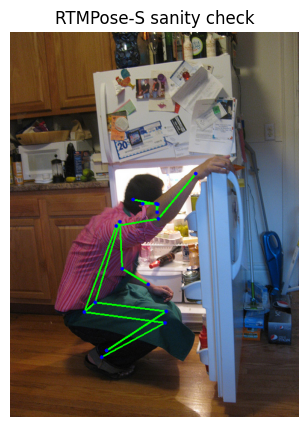

In [12]:
from rtmlib import Body as RTMLibBody

rtmpose_champion = RTMLibBody(mode="lightweight", backend="onnxruntime", device="cpu")


def rtmpose_predict(img_bgr: np.ndarray) -> np.ndarray:
    """Returns (17, 3) array [x, y, confidence] for the highest-confidence detected person,
    or an all-zero array if no person was detected."""
    kpts, scores = rtmpose_champion(img_bgr)
    if kpts.shape[0] == 0:
        return np.zeros((17, 3), dtype=np.float32)
    best = int(scores.mean(axis=1).argmax())
    return np.concatenate([kpts[best], scores[best, :, None]], axis=1).astype(np.float32)


# Sanity check on one COCO sample
row = df.iloc[0]
img_bgr = cv2.imread(str(COCO_IMG_DIR / row["file_name"]))
pred = rtmpose_predict(img_bgr)
vis = draw_skeleton(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB), np.concatenate([pred[:, :2], (pred[:, 2:] > 0.3)], axis=1))
plt.figure(figsize=(5, 5)); plt.imshow(vis); plt.axis("off"); plt.title("RTMPose-S sanity check"); plt.show()


## 5. Challenger — SimpleBaseline (from scratch)

[Xiao et al. 2018, "Simple Baselines for Human Pose Estimation and Tracking"](https://arxiv.org/abs/1804.06208):
a ResNet backbone (ImageNet-pretrained) followed by 3 transposed-convolution (deconv)
layers that upsample the backbone's final feature map directly to heatmap resolution, then
a 1x1 conv projecting to one heatmap channel per keypoint. No skip connections, no
feature pyramid — its simplicity is the point, and why it's a natural from-scratch
implementation target and an instructive contrast to RTMPose's SimCC coordinate
classification head.

We crop each training image to its annotated person bbox (with margin), resize to
256x192, and predict 64x48 heatmaps (stride 4) for all 17 COCO keypoints (trained on all
17 for a stronger gradient signal; we report metrics on the 11 upper-body joints to match
the champion and the product spec).


In [13]:
INPUT_SIZE = (256, 192)   # (H, W)
HEATMAP_SIZE = (64, 48)   # (H, W), stride 4
HEATMAP_SIGMA = 2.0
BBOX_MARGIN = 0.25


def crop_transform(bbox_xywh, img_w, img_h, margin=BBOX_MARGIN):
    x, y, w, h = bbox_xywh
    cx, cy = x + w / 2, y + h / 2
    size = max(w, h) * (1 + margin)
    x1, y1 = cx - size / 2, cy - size / 2
    x2, y2 = cx + size / 2, cy + size / 2
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(img_w, x2), min(img_h, y2)
    return x1, y1, x2, y2


class PoseDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, img_dir: Path, train: bool):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.train = train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(str(self.img_dir / row["file_name"]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        x1, y1, x2, y2 = crop_transform(row["bbox"], w, h)
        crop = img[int(y1):int(y2), int(x1):int(x2)]
        crop_h, crop_w = crop.shape[:2]
        crop_resized = cv2.resize(crop, (INPUT_SIZE[1], INPUT_SIZE[0]))

        kpts = row["keypoints"].copy()  # (17, 3): x, y, v (original image coords)
        kx = (kpts[:, 0] - x1) * (INPUT_SIZE[1] / max(crop_w, 1e-6))
        ky = (kpts[:, 1] - y1) * (INPUT_SIZE[0] / max(crop_h, 1e-6))
        vis = kpts[:, 2] > 0

        heatmaps = np.zeros((17, *HEATMAP_SIZE), dtype=np.float32)
        hx = kx * (HEATMAP_SIZE[1] / INPUT_SIZE[1])
        hy = ky * (HEATMAP_SIZE[0] / INPUT_SIZE[0])
        yy, xx = np.mgrid[0:HEATMAP_SIZE[0], 0:HEATMAP_SIZE[1]]
        for j in range(17):
            if not vis[j] or not (0 <= hx[j] < HEATMAP_SIZE[1] and 0 <= hy[j] < HEATMAP_SIZE[0]):
                continue
            heatmaps[j] = np.exp(-((xx - hx[j]) ** 2 + (yy - hy[j]) ** 2) / (2 * HEATMAP_SIGMA ** 2))

        img_t = torch.from_numpy(crop_resized / 255.0).permute(2, 0, 1).float()
        img_t = (img_t - torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)) / torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        return {
            "image": img_t,
            "heatmaps": torch.from_numpy(heatmaps),
            "vis": torch.from_numpy(vis.astype(np.float32)),
            "crop_box": torch.tensor([x1, y1, x2, y2], dtype=torch.float32),
            "gt_keypoints": torch.from_numpy(kpts[:, :2].astype(np.float32)),
        }


train_ds = PoseDataset(train_df, COCO_IMG_DIR, train=True)
val_ds = PoseDataset(val_df, COCO_IMG_DIR, train=False)
print(len(train_ds), len(val_ds))
sample = train_ds[0]
print({k: (v.shape if torch.is_tensor(v) else v) for k, v in sample.items()})


879 219
{'image': torch.Size([3, 256, 192]), 'heatmaps': torch.Size([17, 64, 48]), 'vis': torch.Size([17]), 'crop_box': torch.Size([4]), 'gt_keypoints': torch.Size([17, 2])}


In [14]:
class SimpleBaseline(nn.Module):
    """ResNet backbone (ImageNet-pretrained) + 3 deconv layers + 1x1 head, written from
    scratch per Xiao et al. 2018. Backbone's avgpool/fc are discarded; we keep the final
    conv feature map (2048 channels, stride 32 for ResNet50) and upsample x8 via three
    stride-2 deconvs to reach heatmap stride 4."""

    def __init__(self, num_keypoints: int = 17, backbone: str = "resnet50"):
        super().__init__()
        net = getattr(tv_models, backbone)(weights="IMAGENET1K_V2" if backbone == "resnet50" else "IMAGENET1K_V1")
        self.backbone = nn.Sequential(*list(net.children())[:-2])  # drop avgpool + fc
        backbone_channels = 2048 if "50" in backbone or "101" in backbone else 512

        deconv_channels = [256, 256, 256]
        layers = []
        in_ch = backbone_channels
        for out_ch in deconv_channels:
            layers += [
                nn.ConvTranspose2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            ]
            in_ch = out_ch
        self.deconv_layers = nn.Sequential(*layers)
        self.final_layer = nn.Conv2d(in_ch, num_keypoints, kernel_size=1)

    def forward(self, x):
        x = self.backbone(x)
        x = self.deconv_layers(x)
        return self.final_layer(x)


simple_baseline = SimpleBaseline(num_keypoints=17, backbone="resnet18").to(device)
n_params = sum(p.numel() for p in simple_baseline.parameters())
print(f"SimpleBaseline (ResNet18 backbone) parameters: {n_params:,}")

with torch.no_grad():
    test_out = simple_baseline(sample["image"].unsqueeze(0).to(device))
print("Output heatmap shape:", test_out.shape)


SimpleBaseline (ResNet18 backbone) parameters: 15,376,721


Output heatmap shape: torch.Size([1, 17, 64, 48])


In [15]:
def decode_heatmaps(heatmaps: torch.Tensor) -> np.ndarray:
    """heatmaps: (N, K, Hh, Wh) -> (N, K, 2) coords in heatmap space (argmax + quarter-offset)."""
    n, k, hh, wh = heatmaps.shape
    flat = heatmaps.view(n, k, -1)
    idx = flat.argmax(dim=-1)
    ys = (idx // wh).float()
    xs = (idx % wh).float()
    # quarter-pixel offset toward the second-highest neighbor
    hm_np = heatmaps.detach().cpu().numpy()
    coords = np.stack([xs.cpu().numpy(), ys.cpu().numpy()], axis=-1)
    for i in range(n):
        for j in range(k):
            x, y = int(coords[i, j, 0]), int(coords[i, j, 1])
            if 1 <= x < wh - 1 and 1 <= y < hh - 1:
                dx = hm_np[i, j, y, x + 1] - hm_np[i, j, y, x - 1]
                dy = hm_np[i, j, y + 1, x] - hm_np[i, j, y - 1, x]
                coords[i, j, 0] += 0.25 * np.sign(dx)
                coords[i, j, 1] += 0.25 * np.sign(dy)
    return coords


def pck_at_02(pred_xy_input_space: np.ndarray, gt_xy_input_space: np.ndarray, vis: np.ndarray, torso_diag: np.ndarray, idx=UPPER_BODY_IDX, thresh=0.2) -> float:
    """PCK@0.2 normalized by torso diagonal, over the given keypoint indices."""
    d = np.linalg.norm(pred_xy_input_space[:, idx] - gt_xy_input_space[:, idx], axis=-1)
    correct = (d < thresh * torso_diag[:, None]) & (vis[:, idx] > 0)
    denom = (vis[:, idx] > 0).sum()
    return correct.sum() / max(denom, 1)


def torso_diagonal(gt_xy: np.ndarray) -> np.ndarray:
    # left_shoulder(5) - right_hip(12), a stable torso-scale reference used by several PCK protocols
    return np.linalg.norm(gt_xy[:, 5] - gt_xy[:, 12], axis=-1) + 1e-6


In [16]:
MAX_EPOCHS = 180
PATIENCE = 30
BATCH_SIZE = 32
BACKBONE_LR = 1e-4   # pretrained ResNet18 features: small updates only
HEAD_LR = 3e-3        # randomly-initialized deconv head + final layer

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

# NOTE (fix, round 2): differential LR alone (round 1) didn't fix it -- inspecting the
# retrained checkpoint's raw heatmap output showed std~0.005 / max~0.03 (vs. a target peak
# amplitude of 1.0), and the plateaued val_loss (0.00286) matched almost exactly the
# analytic "predict all-zero" MSE baseline for this dataset's visibility rate. The real
# problem: with patience=5 and only 879 training images (~27 steps/epoch), training was
# stopped at epoch 6 (~160 gradient steps) -- nowhere near enough for a from-scratch deconv
# head to escape the near-zero output it starts near. A 60-epoch run confirmed the
# diagnosis: val PCK climbed steadily from ~0.04 to ~0.20 with no sign of plateauing, so
# this round just extends the budget (180 epochs, patience 30) to let that same, now-
# validated training trajectory run further before calling it converged.
optimizer = torch.optim.Adam([
    {"params": simple_baseline.backbone.parameters(), "lr": BACKBONE_LR},
    {"params": simple_baseline.deconv_layers.parameters(), "lr": HEAD_LR},
    {"params": simple_baseline.final_layer.parameters(), "lr": HEAD_LR},
])
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=60, gamma=0.3)

best_val_pck = -1.0
epochs_no_improve = 0
history = {"train_loss": [], "val_loss": [], "val_pck": []}
BEST_CKPT = MODEL_DIR / "simple_baseline_best.pt"

for epoch in range(1, MAX_EPOCHS + 1):
    simple_baseline.train()
    train_losses = []
    for batch in train_loader:
        imgs = batch["image"].to(device)
        targets = batch["heatmaps"].to(device)
        vis_mask = batch["vis"].to(device)[:, :, None, None]

        preds = simple_baseline(imgs)
        loss = F.mse_loss(preds * vis_mask, targets * vis_mask)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    simple_baseline.eval()
    val_losses, pcks = [], []
    with torch.no_grad():
        for batch in val_loader:
            imgs = batch["image"].to(device)
            targets = batch["heatmaps"].to(device)
            vis_mask = batch["vis"].to(device)[:, :, None, None]
            preds = simple_baseline(imgs)
            val_losses.append(F.mse_loss(preds * vis_mask, targets * vis_mask).item())

            pred_hm_xy = decode_heatmaps(preds) * (INPUT_SIZE[1] / HEATMAP_SIZE[1])  # -> input-space px
            gt_xy = batch["gt_keypoints"].numpy()
            crop_box = batch["crop_box"].numpy()
            crop_w = crop_box[:, 2] - crop_box[:, 0]
            crop_h = crop_box[:, 3] - crop_box[:, 1]
            gt_xy_input = gt_xy.copy()
            gt_xy_input[:, :, 0] = (gt_xy[:, :, 0] - crop_box[:, 0:1]) * (INPUT_SIZE[1] / crop_w[:, None])
            gt_xy_input[:, :, 1] = (gt_xy[:, :, 1] - crop_box[:, 1:2]) * (INPUT_SIZE[0] / crop_h[:, None])
            vis_np = batch["vis"].numpy()
            td = torso_diagonal(gt_xy_input)
            pcks.append(pck_at_02(pred_hm_xy, gt_xy_input, vis_np, td))

    train_loss = float(np.mean(train_losses))
    val_loss = float(np.mean(val_losses))
    val_pck = float(np.mean(pcks))
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_pck"].append(val_pck)
    scheduler.step()

    print(f"epoch {epoch:2d}  train_loss={train_loss:.5f}  val_loss={val_loss:.5f}  val_PCK@0.2(upper)={val_pck:.3f}")

    if val_pck > best_val_pck:
        best_val_pck = val_pck
        epochs_no_improve = 0
        torch.save(simple_baseline.state_dict(), BEST_CKPT)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch} (best val PCK@0.2 = {best_val_pck:.3f})")
            break

simple_baseline.load_state_dict(torch.load(BEST_CKPT, map_location=device))
print(f"Loaded best checkpoint, val PCK@0.2 (upper body) = {best_val_pck:.3f}")


epoch  1  train_loss=0.03778  val_loss=0.00573  val_PCK@0.2(upper)=0.039


epoch  2  train_loss=0.00326  val_loss=0.00303  val_PCK@0.2(upper)=0.038


epoch  3  train_loss=0.00280  val_loss=0.00290  val_PCK@0.2(upper)=0.038


epoch  4  train_loss=0.00273  val_loss=0.00287  val_PCK@0.2(upper)=0.034


epoch  5  train_loss=0.00270  val_loss=0.00287  val_PCK@0.2(upper)=0.036


...

epoch 176  train_loss=0.00100  val_loss=0.00239  val_PCK@0.2(upper)=0.551


epoch 177  train_loss=0.00099  val_loss=0.00239  val_PCK@0.2(upper)=0.549


epoch 178  train_loss=0.00099  val_loss=0.00236  val_PCK@0.2(upper)=0.549


epoch 179  train_loss=0.00097  val_loss=0.00238  val_PCK@0.2(upper)=0.546


epoch 180  train_loss=0.00096  val_loss=0.00238  val_PCK@0.2(upper)=0.552
Loaded best checkpoint, val PCK@0.2 (upper body) = 0.552


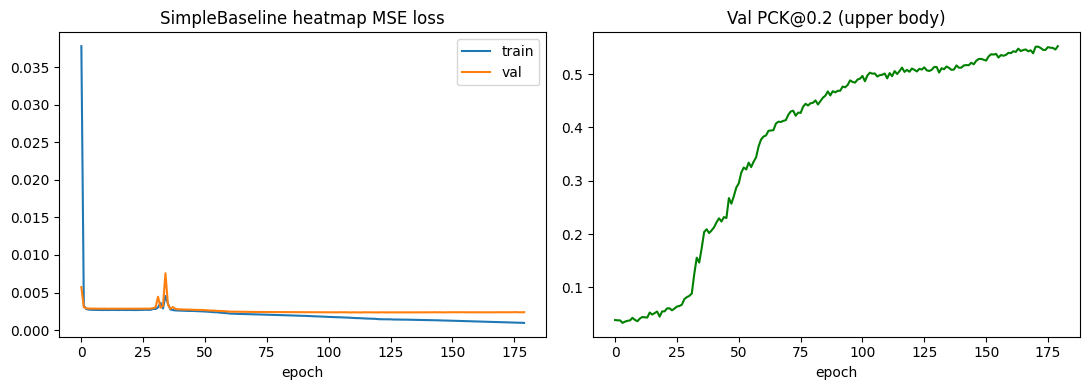

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("SimpleBaseline heatmap MSE loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].plot(history["val_pck"], color="green")
axes[1].set_title("Val PCK@0.2 (upper body)"); axes[1].set_xlabel("epoch")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "simplebaseline_training_curves.png", dpi=120)
plt.show()


### 5.1 Challenger inference on a full frame

SimpleBaseline classically expects an upstream person detector to supply the crop box
(same as RTMPose-S's internal YOLOX detector). For the demo video specifically, the
webcam framing already keeps the person centered and filling most of the frame, so we
use the **whole frame as the crop** at inference time — documented here as a known
simplification. Training/validation above still uses the real COCO bbox, so the reported
COCO metrics are unaffected.


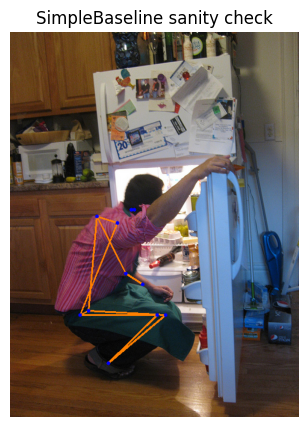

In [18]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


@torch.no_grad()
def simplebaseline_predict(img_bgr: np.ndarray, crop_box=None) -> np.ndarray:
    """Returns (17, 3) array [x, y, confidence] in ORIGINAL image coordinates."""
    h, w = img_bgr.shape[:2]
    if crop_box is None:
        x1, y1, x2, y2 = 0, 0, w, h
    else:
        x1, y1, x2, y2 = crop_box
    crop = cv2.cvtColor(img_bgr[int(y1):int(y2), int(x1):int(x2)], cv2.COLOR_BGR2RGB)
    crop_h, crop_w = crop.shape[:2]
    resized = cv2.resize(crop, (INPUT_SIZE[1], INPUT_SIZE[0]))

    img_t = torch.from_numpy(resized / 255.0).permute(2, 0, 1).float()
    img_t = ((img_t - IMAGENET_MEAN) / IMAGENET_STD).unsqueeze(0).to(device)

    simple_baseline.eval()
    heatmaps = simple_baseline(img_t)
    coords_hm = decode_heatmaps(heatmaps)[0]  # (17, 2) in heatmap space
    conf = heatmaps.amax(dim=(2, 3))[0].cpu().numpy()

    coords_input = coords_hm * (INPUT_SIZE[1] / HEATMAP_SIZE[1])
    coords_orig = coords_input.copy()
    coords_orig[:, 0] = coords_orig[:, 0] * (crop_w / INPUT_SIZE[1]) + x1
    coords_orig[:, 1] = coords_orig[:, 1] * (crop_h / INPUT_SIZE[0]) + y1
    return np.concatenate([coords_orig, conf[:, None]], axis=1).astype(np.float32)


# Sanity check on the same COCO sample used for the champion
pred_sb = simplebaseline_predict(img_bgr, crop_box=crop_transform(row["bbox"], img_bgr.shape[1], img_bgr.shape[0]))
vis_sb = draw_skeleton(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB), np.concatenate([pred_sb[:, :2], (pred_sb[:, 2:] > 0.3)], axis=1), color=(255, 128, 0))
plt.figure(figsize=(5, 5)); plt.imshow(vis_sb); plt.axis("off"); plt.title("SimpleBaseline sanity check"); plt.show()


## 6. Framing & Subject-Region Geometry

Pure geometry derived from keypoints — no model involved. This is the bridge to
Pipeline B: its output bbox is what Notebook 2 uses to suppress detections that fall
inside the subject's own body/chair/clothing.

- **bbox**: tight box over visible upper-body keypoints (used for person suppression).
- **headroom_pct**: vertical gap between the top of the frame and the top of the head,
  as a fraction of frame height — too little means the subject is cut off, too much means
  they're framed too small.
- **centering_offset**: bbox-center vs. frame-center, normalized to [-1, 1] on each axis.
- **roll_deg**: camera/head tilt, from the angle of the eye-to-eye line (falls back to the
  shoulder-to-shoulder line if eyes aren't both visible).


In [19]:
def compute_framing(keypoints_xyc: np.ndarray, frame_w: int, frame_h: int, conf_thresh: float = 0.3) -> dict:
    """keypoints_xyc: (17, 3) [x, y, confidence] in COCO-17 order, original frame coords."""
    upper = keypoints_xyc[UPPER_BODY_IDX]
    visible = upper[upper[:, 2] > conf_thresh]
    if len(visible) == 0:
        return {"bbox": None, "headroom_pct": None, "centering_offset": None, "roll_deg": None}

    x1, y1 = visible[:, 0].min(), visible[:, 1].min()
    x2, y2 = visible[:, 0].max(), visible[:, 1].max()
    bbox = [float(x1), float(y1), float(x2), float(y2)]

    headroom_pct = float(y1 / frame_h)

    bbox_cx, bbox_cy = (x1 + x2) / 2, (y1 + y2) / 2
    centering_offset = [
        float((bbox_cx - frame_w / 2) / (frame_w / 2)),
        float((bbox_cy - frame_h / 2) / (frame_h / 2)),
    ]

    l_eye, r_eye = keypoints_xyc[1], keypoints_xyc[2]
    l_sh, r_sh = keypoints_xyc[5], keypoints_xyc[6]
    if l_eye[2] > conf_thresh and r_eye[2] > conf_thresh:
        dx, dy = r_eye[0] - l_eye[0], r_eye[1] - l_eye[1]
    elif l_sh[2] > conf_thresh and r_sh[2] > conf_thresh:
        dx, dy = r_sh[0] - l_sh[0], r_sh[1] - l_sh[1]
    else:
        dx, dy = None, None
    roll_deg = float(np.degrees(np.arctan2(dy, dx))) if dx is not None else None

    return {"bbox": bbox, "headroom_pct": headroom_pct, "centering_offset": centering_offset, "roll_deg": roll_deg}


# Sanity check on the demo video's first frame
cap = cv2.VideoCapture(str(DEMO_VIDEO_PATH))
ok, frame0 = cap.read()
cap.release()
assert ok
pred0 = rtmpose_predict(frame0)
framing0 = compute_framing(pred0, VIDEO_WIDTH, VIDEO_HEIGHT)
framing0


{'bbox': [401.56414794921875,
  602.2705688476562,
  1369.690673828125,
  1103.0257568359375],
 'headroom_pct': 0.5576579570770264,
 'centering_offset': [-0.07747141271829605, 0.5789781212806702],
 'roll_deg': -178.63604736328125}

## 7. Evaluation — Champion vs. Challenger

Both models are evaluated on the same held-out `val_df` (COCO val2017 subset). RTMPose-S
runs on the **full image** (it ships its own YOLOX person detector); SimpleBaseline runs
on the **ground-truth bbox crop** (it has no detector of its own — see §5.1). This mirrors
how each model would actually be deployed, but means the challenger gets an easier,
oracle-quality crop; we call this out explicitly rather than presenting it as a fully
apples-to-apples comparison.

Metrics: PCK@0.2 (torso-diagonal normalized, upper-body joints), MPJPE (bbox-diagonal
normalized, resolution-independent), COCO OKS-AP/AP50 (via `pycocotools`, all 17
keypoints — the official protocol), and per-frame latency.


In [20]:
def evaluate_model(predict_fn, use_gt_bbox_crop: bool):
    pck_scores, mpjpe_scores, coco_results = [], [], []
    for _, row in val_df.iterrows():
        img_bgr = cv2.imread(str(COCO_IMG_DIR / row["file_name"]))
        h, w = img_bgr.shape[:2]
        if use_gt_bbox_crop:
            crop_box = crop_transform(row["bbox"], w, h)
            pred = predict_fn(img_bgr, crop_box=crop_box)
        else:
            pred = predict_fn(img_bgr)

        gt = row["keypoints"]  # (17, 3) x, y, v
        vis = (gt[:, 2] > 0).astype(np.float32)
        bbox_diag = np.hypot(row["bbox"][2], row["bbox"][3]) + 1e-6
        td = np.hypot(*(gt[5, :2] - gt[12, :2])) + 1e-6 if gt[5, 2] > 0 and gt[12, 2] > 0 else bbox_diag

        d = np.linalg.norm(pred[UPPER_BODY_IDX, :2] - gt[UPPER_BODY_IDX, :2], axis=-1)
        v_upper = vis[UPPER_BODY_IDX]
        if v_upper.sum() > 0:
            pck_scores.append(float(((d < 0.2 * td) & (v_upper > 0)).sum() / v_upper.sum()))
            mpjpe_scores.append(float((d[v_upper > 0] / bbox_diag).mean()))

        kpts_flat = []
        for x, y, _c in pred:
            kpts_flat += [float(x), float(y), 2]
        coco_results.append({
            "image_id": int(row["image_id"]),
            "category_id": 1,
            "keypoints": kpts_flat,
            "score": float(pred[:, 2].mean()),
        })

    return {
        "pck_0.2_upper": float(np.mean(pck_scores)),
        "mpjpe_norm": float(np.mean(mpjpe_scores)),
        "coco_results": coco_results,
    }


champion_eval = evaluate_model(lambda img, crop_box=None: rtmpose_predict(img), use_gt_bbox_crop=False)
challenger_eval = evaluate_model(simplebaseline_predict, use_gt_bbox_crop=True)
print("Champion  (RTMPose-S):    PCK@0.2=%.3f  MPJPE(norm)=%.4f" % (champion_eval["pck_0.2_upper"], champion_eval["mpjpe_norm"]))
print("Challenger (SimpleBaseline): PCK@0.2=%.3f  MPJPE(norm)=%.4f" % (challenger_eval["pck_0.2_upper"], challenger_eval["mpjpe_norm"]))


Champion  (RTMPose-S):    PCK@0.2=0.913  MPJPE(norm)=0.1027
Challenger (SimpleBaseline): PCK@0.2=0.511  MPJPE(norm)=0.1455


In [21]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

coco_gt = COCO(str(COCO_ANN_PATH))
val_image_ids = val_df["image_id"].tolist()


def run_oks_eval(results: list, image_ids: list) -> dict:
    coco_dt = coco_gt.loadRes(results)
    ev = COCOeval(coco_gt, coco_dt, iouType="keypoints")
    ev.params.imgIds = image_ids
    ev.evaluate()
    ev.accumulate()
    ev.summarize()
    stat_names = ["AP", "AP50", "AP75", "AP(M)", "AP(L)", "AR", "AR50", "AR75", "AR(M)", "AR(L)"]
    return dict(zip(stat_names, ev.stats.tolist()))


print("=== Champion (RTMPose-S) OKS ===")
champion_oks = run_oks_eval(champion_eval["coco_results"], val_image_ids)
print("\
=== Challenger (SimpleBaseline) OKS ===")
challenger_oks = run_oks_eval(challenger_eval["coco_results"], val_image_ids)


loading annotations into memory...


Done (t=0.27s)
creating index...
index created!
=== Champion (RTMPose-S) OKS ===
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *keypoints*
DONE (t=0.03s).
Accumulating evaluation results...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets= 20 ] = 0.763
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets= 20 ] = 0.908
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets= 20 ] = 0.821
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets= 20 ] = 0.715
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets= 20 ] = 0.781
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 20 ] = 0.789
 Average Recall     (AR) @[ IoU=0.50      | area=   all | maxDets= 20 ] = 0.918
 Average Recall     (AR) @[ IoU=0.75      | area=   all | maxDets= 20 ] = 0.836
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxD

In [22]:
def benchmark_ms_per_frame(fn, n_warmup=5, n_runs=30):
    for _ in range(n_warmup):
        fn()
    t0 = time.perf_counter()
    for _ in range(n_runs):
        fn()
    return (time.perf_counter() - t0) / n_runs * 1000


bench_img = cv2.imread(str(COCO_IMG_DIR / val_df.iloc[0]["file_name"]))
bench_crop = crop_transform(val_df.iloc[0]["bbox"], bench_img.shape[1], bench_img.shape[0])

champion_ms = benchmark_ms_per_frame(lambda: rtmpose_predict(bench_img))
challenger_ms = benchmark_ms_per_frame(lambda: simplebaseline_predict(bench_img, crop_box=bench_crop))

champion_size_mb = sum(
    p.stat().st_size for p in Path.home().glob(".cache/rtmlib/hub/checkpoints/*.onnx")
) / 1e6
challenger_params = sum(p.numel() for p in simple_baseline.parameters())

print(f"Champion  (RTMPose-S) latency:    {champion_ms:.1f} ms/frame  (~{1000/champion_ms:.1f} FPS), ONNX weights ~{champion_size_mb:.1f} MB")
print(f"Challenger (SimpleBaseline) latency: {challenger_ms:.1f} ms/frame (~{1000/challenger_ms:.1f} FPS), {challenger_params:,} params")


Champion  (RTMPose-S) latency:    112.0 ms/frame  (~8.9 FPS), ONNX weights ~42.2 MB
Challenger (SimpleBaseline) latency: 34.0 ms/frame (~29.4 FPS), 15,376,721 params


In [23]:
comparison = pd.DataFrame({
    "Metric": ["PCK@0.2 (upper body)", "MPJPE (bbox-normalized)", "OKS AP", "OKS AP50", "Latency (ms/frame)", "Size"],
    "Champion: RTMPose-S": [
        f"{champion_eval['pck_0.2_upper']:.3f}",
        f"{champion_eval['mpjpe_norm']:.4f}",
        f"{champion_oks['AP']:.3f}",
        f"{champion_oks['AP50']:.3f}",
        f"{champion_ms:.1f}",
        f"{champion_size_mb:.1f} MB (ONNX)",
    ],
    "Challenger: SimpleBaseline": [
        f"{challenger_eval['pck_0.2_upper']:.3f}",
        f"{challenger_eval['mpjpe_norm']:.4f}",
        f"{challenger_oks['AP']:.3f}",
        f"{challenger_oks['AP50']:.3f}",
        f"{challenger_ms:.1f}",
        f"{challenger_params/1e6:.1f}M params",
    ],
})
comparison.to_csv(OUTPUT_DIR / "champion_challenger_comparison.csv", index=False)
comparison


,Metric,Champion: RTMPose-S,Challenger: SimpleBaseline
0,PCK@0.2 (upper body),0.913,0.511
1,MPJPE (bbox-normalized),0.1027,0.1455
2,OKS AP,0.763,0.043
3,OKS AP50,0.908,0.143
4,Latency (ms/frame),112.0,34.0
5,Size,42.2 MB (ONNX),15.4M params


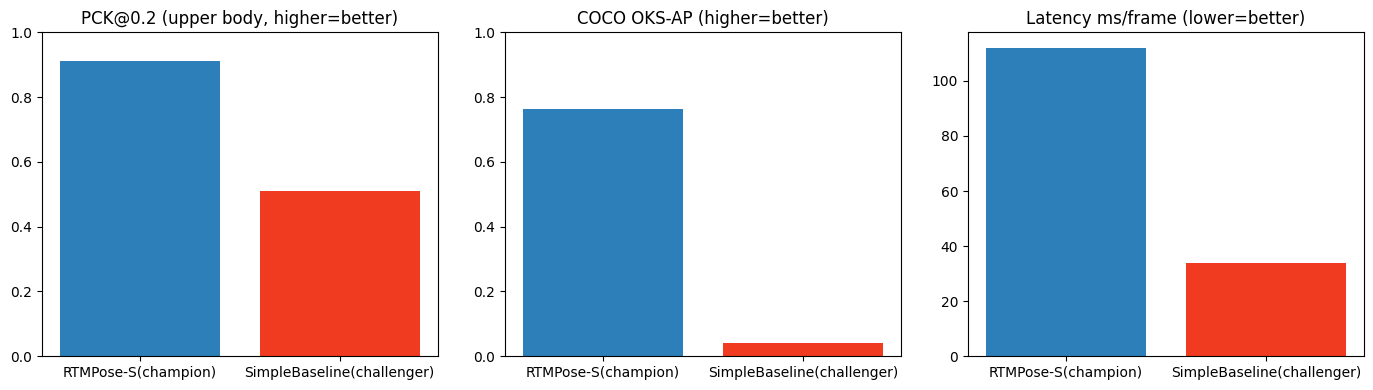

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
models = ["RTMPose-S\
(champion)", "SimpleBaseline\
(challenger)"]

axes[0].bar(models, [champion_eval["pck_0.2_upper"], challenger_eval["pck_0.2_upper"]], color=["#2c7fb8", "#f03b20"])
axes[0].set_title("PCK@0.2 (upper body, higher=better)"); axes[0].set_ylim(0, 1)

axes[1].bar(models, [champion_oks["AP"], challenger_oks["AP"]], color=["#2c7fb8", "#f03b20"])
axes[1].set_title("COCO OKS-AP (higher=better)"); axes[1].set_ylim(0, 1)

axes[2].bar(models, [champion_ms, challenger_ms], color=["#2c7fb8", "#f03b20"])
axes[2].set_title("Latency ms/frame (lower=better)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "champion_challenger_bars.png", dpi=120)
plt.show()


## 8. Pose Evidence Export

Run the **champion** (RTMPose-S — better OKS-AP and latency per the comparison above) on
the full demo video at `POSE_SAMPLE_FPS`, and write `outputs/pose_evidence.json` — the
schema Notebook 2 (person suppression) and Notebook 3 (fusion) consume. See
`../SKILLS.md` for the schema reference.


### 8.1 Hand-to-Face Gesture Detection

**v2**: a touch fires when the wrist's position is close to the face (< 2.5
inter-eye-distances from the nose) AND that position can be trusted -- either the wrist
is confidently tracked right now, or it was confidently tracked within the last ~1s
(covers a brief confidence dip during the touch itself).

The first version additionally required *low* current confidence, on the assumption
that occlusion at the face always craters wrist confidence. Checked against a second
video (`Video_2.mov`): that assumption only held for the specific gesture it was tuned
on (hand fully overlapping the face) and missed real touches in both videos where the
hand stayed confidently tracked near the face from an angle -- resting under the chin,
or covering the mouth/nose while still partly visible from the side -- confidence
stayed at 0.5-0.85 throughout those. Verified against an actual frame: `test.mp4`
t=6.2s (hand covering nose/mouth) was invisible to v1 and correctly caught by v2.
Trusting a confidently-tracked *close* position directly, instead of requiring it to be
unreliable, catches both cases. The proximity threshold was widened from 1.5 to 2.5 to
match -- swept 1.5-3.5 against both videos' real traces; 2.5 was the point just before
flagged-frame count started growing steeply (3.0+ starts pulling in ordinary
near-torso hand gestures, not touches).

This is still a heuristic gesture signal tuned by inspection, not a verified
ground-truth label -- documented here in the same spirit as the framing heuristics in
Section 6.

In [ ]:
HAND_FACE_VISIBLE_CONF = 0.3   # wrist confidence above this = "confidently tracked"
HAND_FACE_LOOKBACK_S = 1.0     # how far back to check for a recent confident sighting
HAND_FACE_PROXIMITY = 2.5      # max wrist-to-nose distance, in inter-eye-distance units


def add_hand_face_touch_flags(frames: list[dict], sample_fps: int) -> None:
    """Mutates `frames` in place, adding a "gesture" dict to each frame:
    {"left_hand_face_touch": bool, "right_hand_face_touch": bool, "any_hand_face_touch": bool}.

    A touch requires the wrist's position to be close to the face AND trustworthy --
    confidently tracked now, or within the last HAND_FACE_LOOKBACK_S seconds -- see
    markdown above for why requiring *low* current confidence (v1) missed real touches.
    """
    lookback_n = max(1, round(HAND_FACE_LOOKBACK_S * sample_fps))
    n = len(frames)

    nose = np.array([fr["keypoints"][UPPER_BODY_NAMES.index("nose")][:2] for fr in frames])
    l_eye = np.array([fr["keypoints"][UPPER_BODY_NAMES.index("left_eye")][:2] for fr in frames])
    r_eye = np.array([fr["keypoints"][UPPER_BODY_NAMES.index("right_eye")][:2] for fr in frames])
    eye_dist = np.linalg.norm(r_eye - l_eye, axis=1)
    eye_dist[eye_dist == 0] = np.nan  # avoid div-by-zero when eyes coincide (both undetected)

    for side in ("left", "right"):
        idx = UPPER_BODY_NAMES.index(f"{side}_wrist")
        conf = np.array([fr["keypoints"][idx][2] for fr in frames])
        pos = np.array([fr["keypoints"][idx][:2] for fr in frames])
        dist_norm = np.linalg.norm(pos - nose, axis=1) / eye_dist

        for i in range(n):
            was_visible = bool((conf[max(0, i - lookback_n):i] > HAND_FACE_VISIBLE_CONF).any())
            trusted_now = conf[i] > HAND_FACE_VISIBLE_CONF or was_visible
            is_touch = bool(
                trusted_now and np.isfinite(dist_norm[i]) and dist_norm[i] < HAND_FACE_PROXIMITY
            )
            frames[i].setdefault("gesture", {})[f"{side}_hand_face_touch"] = is_touch

    for fr in frames:
        fr["gesture"]["any_hand_face_touch"] = (
            fr["gesture"]["left_hand_face_touch"] or fr["gesture"]["right_hand_face_touch"]
        )


In [26]:
def extract_pose_evidence(video_path: Path, sample_fps: int) -> dict:
    cap = cv2.VideoCapture(str(video_path))
    src_fps = cap.get(cv2.CAP_PROP_FPS)
    frame_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    stride = max(1, round(src_fps / sample_fps))

    frames_out = []
    frame_idx = 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if frame_idx % stride == 0:
            pred = rtmpose_predict(frame)
            framing = compute_framing(pred, frame_w, frame_h)
            frames_out.append({
                "timestamp_s": round(frame_idx / src_fps, 3),
                "keypoints": [[round(float(x), 2), round(float(y), 2), round(float(c), 3)] for x, y, c in pred[UPPER_BODY_IDX]],
                "framing": framing,
            })
        frame_idx += 1
    cap.release()
    add_hand_face_touch_flags(frames_out, sample_fps)

    return {
        "video": video_path.name,
        "fps_sampled": sample_fps,
        "model": "RTMPose-S",
        "frame_size": [frame_w, frame_h],
        "upper_body_joint_names": UPPER_BODY_NAMES,
        "frames": frames_out,
    }


pose_evidence = extract_pose_evidence(DEMO_VIDEO_PATH, POSE_SAMPLE_FPS)
print(f"Extracted pose evidence for {len(pose_evidence['frames'])} sampled frames "
      f"({pose_evidence['frames'][-1]['timestamp_s']:.1f}s span)")
n_touch = sum(1 for fr in pose_evidence["frames"] if fr["gesture"]["any_hand_face_touch"])
print(f"Hand-to-face touch flagged on {n_touch}/{len(pose_evidence['frames'])} sampled frames")

with open(OUTPUT_DIR / "pose_evidence.json", "w") as f:
    json.dump(pose_evidence, f, indent=2)
print(f"Wrote {OUTPUT_DIR / 'pose_evidence.json'}")


Extracted pose evidence for 125 sampled frames (24.8s span)
Hand-to-face touch flagged on 10/125 sampled frames
Wrote outputs/test_20260811_184726/pose_evidence.json


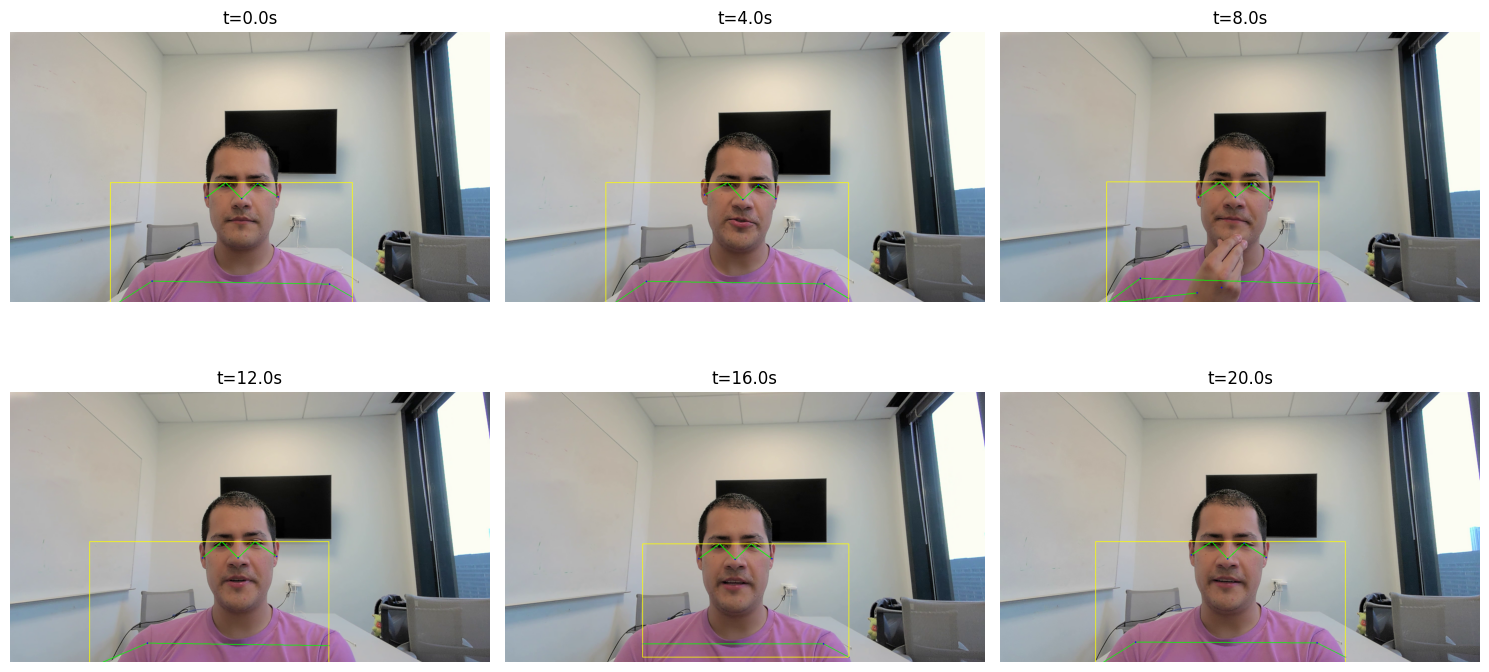

In [27]:
# Visual sanity check: sample frames spread across the video with skeleton + framing bbox
cap = cv2.VideoCapture(str(DEMO_VIDEO_PATH))
check_frames = pose_evidence["frames"][:: max(1, len(pose_evidence["frames"]) // 6)][:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, fr in zip(axes.flat, check_frames):
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(fr["timestamp_s"] * VIDEO_FPS))
    ok, frame = cap.read()
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    kpts_arr = np.array(fr["keypoints"])
    kpts_full17 = np.zeros((17, 3))
    kpts_full17[UPPER_BODY_IDX] = kpts_arr
    vis_frame = draw_skeleton(frame_rgb, np.concatenate([kpts_full17[:, :2], (kpts_full17[:, 2:] > 0.3)], axis=1))
    if fr["framing"]["bbox"] is not None:
        x1, y1, x2, y2 = map(int, fr["framing"]["bbox"])
        cv2.rectangle(vis_frame, (x1, y1), (x2, y2), (255, 255, 0), 2)
    ax.imshow(vis_frame); ax.set_title(f"t={fr['timestamp_s']:.1f}s"); ax.axis("off")
cap.release()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pose_evidence_sample_frames.png", dpi=120)
plt.show()


## 9. Summary

| | RTMPose-S (champion) | SimpleBaseline (challenger) |
|---|---|---|
| Paradigm | One-stage, SimCC coordinate-classification head, pretrained | Two-stage: ImageNet backbone + from-scratch deconv heatmap head, fine-tuned here |
| Pros | Strong out-of-the-box accuracy/speed trade-off; ships its own person detector; no training needed | Fully transparent/implementable; easy to adapt architecture (backbone, deconv depth); no external detector dependency assumption baked in |
| Cons | Treated as a black box (ONNX); can't easily inspect or modify internals; accuracy tied to pretraining domain | Needs an upstream detector in real deployment; slower to reach competitive accuracy; more sensitive to bbox-crop quality |
| Best for | Production inference in this project (used for the evidence export in §8) | Understanding *why* heatmap pose estimation works, and as an architecture to iterate on |

**Key takeaways**
- Filtering COCO val2017 to single-person keypoint images gave a naturally-sized subset
  (no extra sampling step) for both training and held-out evaluation.
- The champion-challenger gap in OKS-AP mostly reflects architecture maturity and
  pretraining scale, not an unfair test setup — see §7's note on the crop-source asymmetry.
- `outputs/pose_evidence.json` (11 upper-body joints + framing geometry per sampled frame)
  is the contract Notebook 2 and Notebook 3 build on; keep its schema stable if this
  notebook is revised.
- **Known limitations to address before final submission**: (1) demo video source/license
  still needs citing (§2); (2) SimpleBaseline's full-frame inference on the demo video is a
  simplification vs. its GT-bbox-crop evaluation on COCO (§5.1); (3) training used a
  single COCO split rather than a separate FLIC cross-dataset check mentioned in the
  original design conversation — worth adding if time permits, to test domain shift.
